# Hierarchical and Grouped Time Series

Time series are often *disaggregated* by attributes of interest.

- *Hierarchical*: attributes are **nested** (e.g. country → state → region).
- *Grouped*: attributes are **crossed** (e.g. gender × legal status) — no unique nesting order.
- *Mixed*: some factors nest, others cross (e.g. geography × purpose of travel).

We want *coherent* forecasts later: child series should add up to their parents.

This notebook focuses on **building and exploring** those structures with [`hierarchicalforecast.utils.aggregate`](https://nixtlaverse.nixtla.io/hierarchicalforecast/utils.html).

Companion slides: `18_hierarchical_and_grouped.typ`.

## Setup

In [1]:
from pathlib import Path
import os
import sys

import warnings

warnings.filterwarnings("ignore")

# Nixtla long-format: keep unique_id as a column (not the index)
os.environ["NIXTLA_ID_AS_COL"] = "true"

LESSON_DIR = Path().resolve()
COURSE_DIR = LESSON_DIR.parent
DATA_DIR = COURSE_DIR / "data"
ASSETS_DIR = COURSE_DIR / "assets"

if str(COURSE_DIR) not in sys.path:
    sys.path.insert(0, str(COURSE_DIR))

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image
from matplotlib.ticker import MaxNLocator

# https://nixtlaverse.nixtla.io/hierarchicalforecast/utils.html
from hierarchicalforecast.utils import aggregate

# https://seaborn.pydata.org/
sns.set_theme(style="whitegrid")

from utils import load_tourism

## Hierarchy Example: Australian Tourism

Australia has six states and two territories (we call them all *states*).

- Each state splits into *tourism regions* (76 in total).
- Planners want forecasts for:
  - the whole country,
  - each state, and
  - each region.

That nesting is a *hierarchical time series*.

### Geography: states and regions

**Figure:** Australian states and tourism regions.

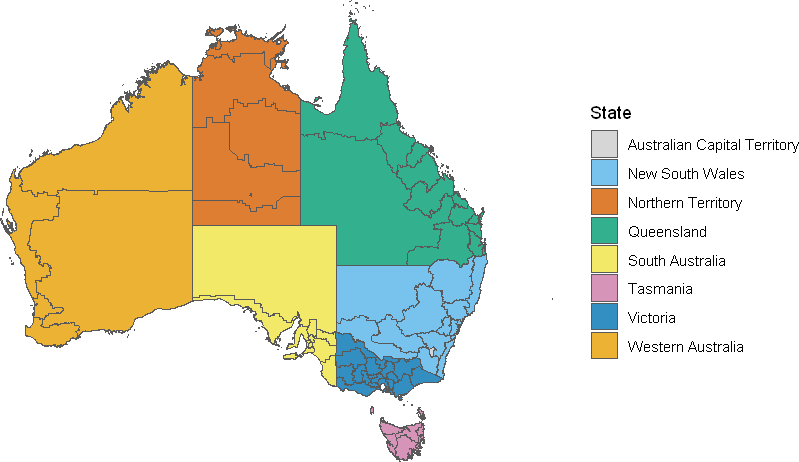

In [3]:
Image(filename=ASSETS_DIR / "aus_tourism_regions.png")

**Table 11.1: Australian tourism regions**

| State | Regions |
| ----- | ------- |
| Australian Capital Territory | Canberra |
| New South Wales | Blue Mountains, Capital Country, Central Coast, Central NSW, Hunter, New England North West, North Coast NSW, Outback NSW, Riverina, Snowy Mountains, South Coast, Sydney, The Murray |
| Northern Territory | Alice Springs, Barkly, Darwin, Kakadu Arnhem, Katherine Daly, Lasseter, MacDonnell |
| Queensland | Brisbane, Bundaberg, Central Queensland, Darling Downs, Fraser Coast, Gold Coast, Mackay, Northern Outback, Sunshine Coast, Tropical North Queensland, Whitsundays |
| South Australia | Adelaide, Adelaide Hills, Barossa, Clare Valley, Eyre Peninsula, Fleurieu Peninsula, Flinders Ranges and Outback, Kangaroo Island, Limestone Coast, Murraylands, Riverland, Yorke Peninsula |
| Tasmania | East Coast, Hobart and the South, Launceston Tamar and the North, North West, Wilderness West |
| Victoria | Ballarat, Bendigo Loddon, Central Highlands, Central Murray, Geelong and the Bellarine, Gippsland, Goulburn, Great Ocean Road, High Country, Lakes, Macedon, Mallee, Melbourne, Melbourne East, Murray East, Peninsula, Phillip Island, Spa Country, Upper Yarra, Western Grampians, Wimmera |
| Western Australia | Australia's Coral Coast, Australia's Golden Outback, Australia's North West, Australia's South West, Experience Perth |

### Load and reshape tourism data

We reuse `load_tourism()` from earlier lessons.

- Keys: `Region`, `State`, `Purpose`
- Target: `Trips` (overnight trips, thousands)
- For a *geographic* hierarchy we temporarily ignore `Purpose` (it returns in the mixed section).

In [4]:
state_abbrev = {
    "Australian Capital Territory": "ACT",
    "New South Wales": "NSW",
    "Northern Territory": "NT",
    "Queensland": "QLD",
    "South Australia": "SA",
    "Tasmania": "TAS",
    "Victoria": "VIC",
    "Western Australia": "WA",
}

tourism = load_tourism().reset_index()

aus_tourism = tourism.assign(
    # Root of every geographic path in unique_id strings
    Country="Australia",
    # Shorter labels keep plots and unique_ids readable
    State=lambda x: x["State"].replace(state_abbrev),
    # hierarchicalforecast expects a datetime column named ds
    ds=lambda x: x["Quarter"].dt.to_timestamp(),
    # and a numeric target named y
    y=lambda x: x["Trips"],
)[["Country", "State", "Region", "Purpose", "ds", "y"]]

display(aus_tourism.head())
print(
    f"{aus_tourism['Region'].nunique()} regions, "
    f"{aus_tourism['State'].nunique()} states, "
    f"{aus_tourism['Purpose'].nunique()} purposes"
)

,Country,State,Region,Purpose,ds,y
0,Australia,SA,Adelaide,Business,1998-01-01,135.077690
1,Australia,SA,Adelaide,Business,1998-04-01,109.987316
2,Australia,SA,Adelaide,Business,1998-07-01,166.034687
3,Australia,SA,Adelaide,Business,1998-10-01,127.160464
4,Australia,SA,Adelaide,Business,1999-01-01,137.448533


76 regions, 8 states, 4 purposes


### Build the hierarchy with `aggregate()`

`spec` is a list of *aggregation levels*.

- Each level is a list of column names from coarsest → finest.
- Nesting (`Country` ⊂ `State` ⊂ `Region`) means each child belongs to exactly one parent.

**Try changing `spec`:**

- Drop `Region` → only national + state series (fewer rows in `Y_df`).
- Drop `State` → invalid nesting for this geography (regions would not roll up through states).

In [5]:
# Nested geographic hierarchy: Country → State → Region
geo_spec = [
    ["Country"],
    ["Country", "State"],
    ["Country", "State", "Region"],
]

# Purpose is crossed later; exclude it so trips sum over purpose within each region
Y_geo, S_geo, tags_geo = aggregate(
    df=aus_tourism.drop(columns=["Purpose"]),
    spec=geo_spec,
)

display(Y_geo.head())
print(f"Y_geo rows: {len(Y_geo):,}  |  series: {Y_geo['unique_id'].nunique()}")
print(f"S_geo shape: {S_geo.shape}  (rows = all series, cols = bottom-level + unique_id)")

,unique_id,ds,y
0,Australia,1998-01-01,23182.197269
1,Australia,1998-04-01,20323.380067
2,Australia,1998-07-01,19826.640511
3,Australia,1998-10-01,20830.129891
4,Australia,1999-01-01,22087.353380


Y_geo rows: 6,800  |  series: 85
S_geo shape: (85, 77)  (rows = all series, cols = bottom-level + unique_id)


`aggregate()` returns three objects:

- `Y_df` — long panel of every series at every level (`unique_id`, `ds`, `y`)
- `S_df` — *summing matrix*: which bottom series add into each upper series
- `tags` — dict mapping level name → list of `unique_id`s at that level

In [6]:
# First few bottom-level columns of the summing matrix
display(S_geo.iloc[:, :6])

for level, unique_ids in tags_geo.items():
    print(f"{level}: {len(unique_ids)} series")
    print(unique_ids[:3], "..." if len(unique_ids) > 3 else "")
    print()

,unique_id,Australia/ACT/Canberra,Australia/NSW/Blue Mountains,Australia/NSW/Capital Country,Australia/NSW/Central Coast,Australia/NSW/Central NSW
0,Australia,1.0,1.0,1.0,1.0,1.0
1,Australia/ACT,1.0,0.0,0.0,0.0,0.0
2,Australia/NSW,0.0,1.0,1.0,1.0,1.0
3,Australia/NT,0.0,0.0,0.0,0.0,0.0
4,Australia/QLD,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
80,Australia/WA/Australia's Coral Coast,0.0,0.0,0.0,0.0,0.0
81,Australia/WA/Australia's Golden Outback,0.0,0.0,0.0,0.0,0.0
82,Australia/WA/Australia's North West,0.0,0.0,0.0,0.0,0.0
83,Australia/WA/Australia's South West,0.0,0.0,0.0,0.0,0.0


Country: 1 series
['Australia'] 

Country/State: 8 series
['Australia/ACT' 'Australia/NSW' 'Australia/NT'] ...

Country/State/Region: 76 series
['Australia/ACT/Canberra' 'Australia/NSW/Blue Mountains'
 'Australia/NSW/Capital Country'] ...



### National and state series

Aggregate totals reveal different dynamics by state (growth since ~2010 in several states; a jump in WA around 2014).

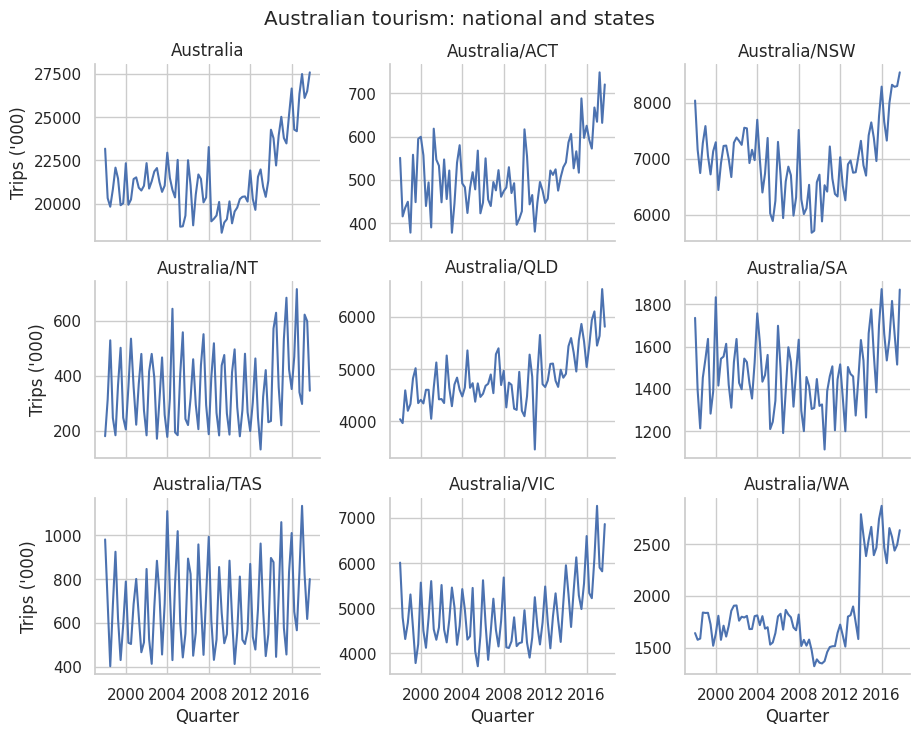

In [7]:
plot_ids = [*tags_geo["Country"], *tags_geo["Country/State"]]
plot_df = Y_geo.loc[Y_geo["unique_id"].isin(plot_ids)].copy()

g = sns.relplot(
    data=plot_df,
    x="ds",
    y="y",
    col="unique_id",
    col_wrap=3,
    kind="line",
    height=2.4,
    aspect=1.3,
    facet_kws={"sharey": False},
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Quarter", "Trips ('000)")
g.fig.suptitle("Australian tourism: national and states", y=1.02)
plt.show()

### Seasonal contrast: north vs south

- *Northern* states (QLD, NT): peaks in winter (Q3) — tropical wet summers.
- *Southern* states (VIC, TAS): peaks in summer (Q1).

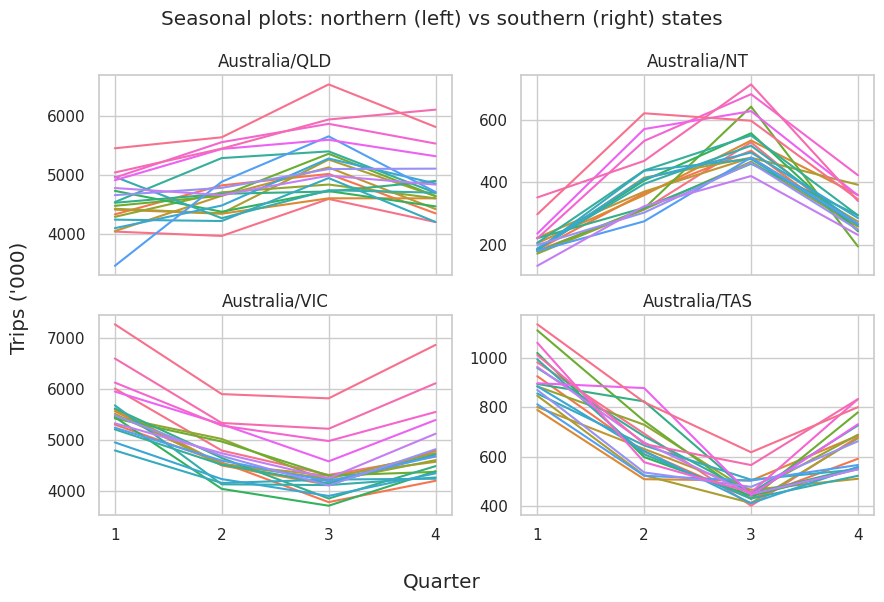

In [8]:
seasonal_states = [
    "Australia/QLD",
    "Australia/NT",
    "Australia/VIC",
    "Australia/TAS",
]

seasonal_df = (
    Y_geo.loc[Y_geo["unique_id"].isin(seasonal_states)]
    .assign(
        year=lambda x: x["ds"].dt.year,
        quarter=lambda x: x["ds"].dt.quarter,
    )
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(9, 6),
    sharex=True,
)

for ax, state_id in zip(axes.flat, seasonal_states):
    state_df = seasonal_df.loc[seasonal_df["unique_id"] == state_id]
    sns.lineplot(
        data=state_df,
        x="quarter",
        y="y",
        hue="year",
        palette="husl",
        ax=ax,
        legend=False,
    )
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title(state_id)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supylabel("Trips ('000)")
fig.supxlabel("Quarter")
fig.suptitle("Seasonal plots: northern (left) vs southern (right) states")
fig.tight_layout()
plt.show()

### Regions nested within states

Selected regions show rich local dynamics: strong trends, contrasting seasonality, or near-noise series.

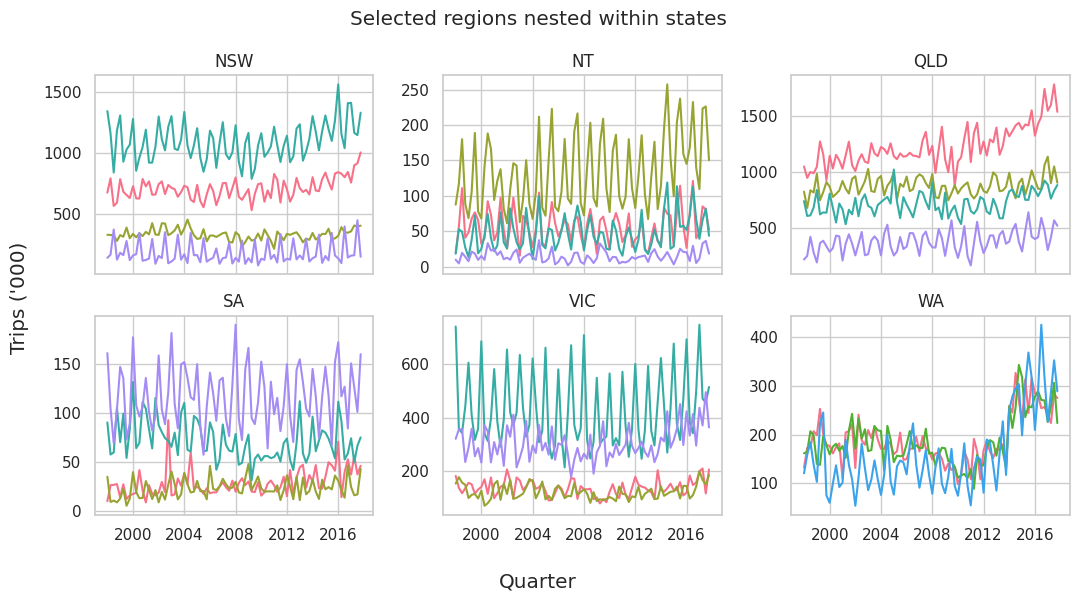

In [9]:
plot_regions = [
    "North Coast NSW",
    "Snowy Mountains",
    "Hunter",
    "New England North West",
    "Alice Springs",
    "Darwin",
    "Kakadu Arnhem",
    "MacDonnell",
    "Brisbane",
    "Gold Coast",
    "Northern Outback",
    "Sunshine Coast",
    "Tropical North Queensland",
    "Adelaide Hills",
    "Murraylands",
    "Yorke Peninsula",
    "Kangaroo Island",
    "Ballarat",
    "Great Ocean Road",
    "High Country",
    "Goulburn",
    "Australia's Coral Coast",
    "Australia's Golden Outback",
    "Australia's North West",
]

# Bottom-level geo series already sum over Purpose
region_ids = [
    uid
    for uid in tags_geo["Country/State/Region"]
    if uid.split("/")[-1] in plot_regions
]
region_df = Y_geo.loc[Y_geo["unique_id"].isin(region_ids)].assign(
    State=lambda x: x["unique_id"].str.split("/").str[1],
    Region=lambda x: x["unique_id"].str.split("/").str[2],
)

plot_states = ["NSW", "NT", "QLD", "SA", "VIC", "WA"]
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(11, 6),
    sharex=True,
)

for ax, state in zip(axes.flat, plot_states):
    state_df = region_df.loc[region_df["State"] == state]
    sns.lineplot(
        data=state_df,
        x="ds",
        y="y",
        hue="Region",
        palette="husl",
        ax=ax,
        legend=False,
    )
    ax.set_title(state)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supylabel("Trips ('000)")
fig.supxlabel("Quarter")
fig.suptitle("Selected regions nested within states")
fig.tight_layout()
plt.show()

## Grouped Example: Australian Prison Population

Prison counts can be split by attributes that are *crossed*, not nested:

- *State*
- *Legal* status (sentenced vs remanded)
- *Gender*
- *Indigenous* status

There is no unique hierarchy: you can group by state first, or by gender first — both are valid.
That is a *grouped time series*.

### Load prison data

In [10]:
prison = (
    pd.read_csv(DATA_DIR / "prison.csv", index_col=0)
    .assign(
        # Quarters like "2005Q1" → period → timestamp at quarter start
        ds=lambda x: pd.PeriodIndex(x["ds"], freq="Q").to_timestamp(),
        Country="Australia",
    )
)

display(prison.head())
print(prison[["State", "Gender", "Legal", "Indigenous"]].nunique())

,ds,State,Gender,Legal,Indigenous,y,Country
1,2005-01-01,ACT,Female,Remanded,ATSI,0,Australia
2,2005-04-01,ACT,Female,Remanded,ATSI,1,Australia
3,2005-07-01,ACT,Female,Remanded,ATSI,0,Australia
4,2005-10-01,ACT,Female,Remanded,ATSI,0,Australia
5,2006-01-01,ACT,Female,Remanded,ATSI,1,Australia


State         8
Gender        2
Legal         2
Indigenous    2
dtype: int64


### Crossed `spec` for grouped series

Unlike the tourism `spec`, levels here are **parallel paths**, not a single nesting.

- `Country/State` and `Country/Gender` are alternative mid-level views of the same bottom series.
- Including both (and pairwise combinations) is what makes the structure *grouped*.

**Try changing `spec`:**

- Remove pairwise levels → fewer mid-level series; bottom series unchanged.
- Swap `Gender` and `Legal` order in a path → different `unique_id` strings, same underlying totals.

In [11]:
prison_spec = [
    ["Country"],
    ["Country", "State"],
    ["Country", "Gender"],
    ["Country", "Legal"],
    ["Country", "Indigenous"],
    ["Country", "State", "Gender"],
    ["Country", "State", "Legal"],
    ["Country", "Legal", "Gender"],
    ["Country", "State", "Legal", "Gender"],
    # Finest bottom level used by FPPPY
    ["Country", "State", "Gender", "Legal", "Indigenous"],
]

Y_prison, S_prison, tags_prison = aggregate(
    df=prison,
    spec=prison_spec,
)

print(f"Series at each level:")
for level, unique_ids in tags_prison.items():
    print(f"  {level}: {len(unique_ids)}")
print(f"\nY_prison shape: {Y_prison.shape}")
display(Y_prison.head())

Series at each level:
  Country: 1
  Country/State: 8
  Country/Gender: 2
  Country/Legal: 2
  Country/Indigenous: 2
  Country/State/Gender: 16
  Country/State/Legal: 16
  Country/Legal/Gender: 4
  Country/State/Legal/Gender: 32
  Country/State/Gender/Legal/Indigenous: 64

Y_prison shape: (7056, 3)


,unique_id,ds,y
0,Australia,2005-01-01,24296
1,Australia,2005-04-01,24643
2,Australia,2005-07-01,24511
3,Australia,2005-10-01,24393
4,Australia,2006-01-01,24524


### Total and single-factor groupings

Scale counts to thousands for readability.

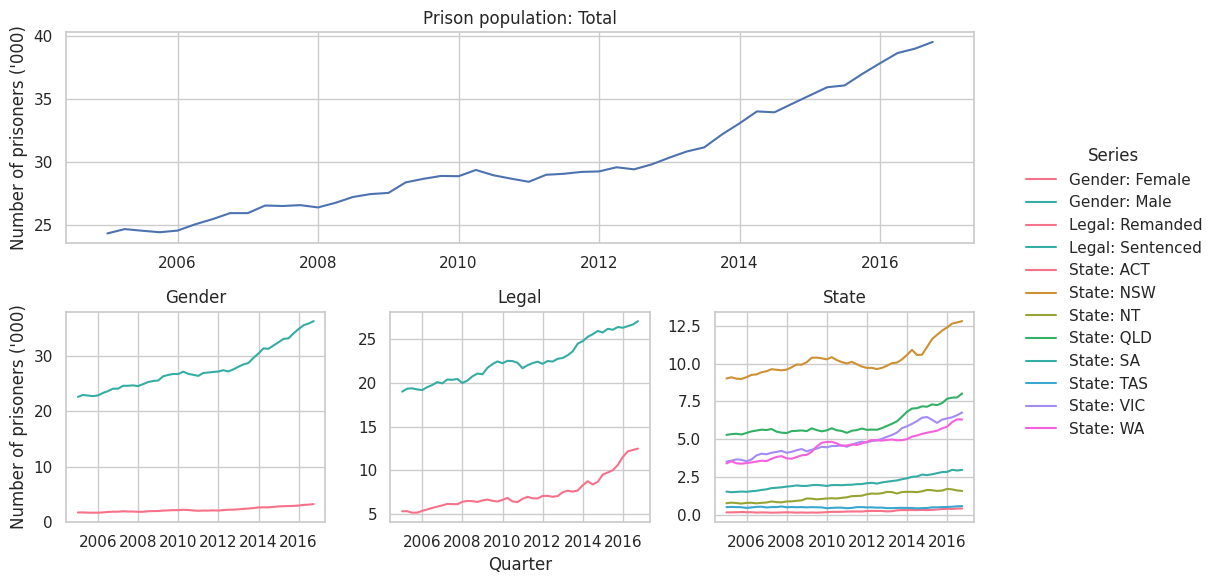

In [12]:
Y_prison_k = Y_prison.assign(y=lambda x: x["y"] / 1e3).set_index("unique_id")

key_columns = ["Gender", "Legal", "State"]
mosaic = [3 * ["Country"], key_columns]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(10, 6))

# Top panel: national total
sns.lineplot(
    data=Y_prison_k.loc["Australia"],
    x="ds",
    y="y",
    ax=axes["Country"],
)
axes["Country"].set_title("Prison population: Total")
axes["Country"].set_xlabel("")
axes["Country"].set_ylabel("Number of prisoners ('000)")

all_handles, all_labels = [], []
for key_column in key_columns:
    labels = prison[key_column].unique()
    legend_labels = [f"{key_column}: {label}" for label in labels]
    label_data = pd.concat(
        [Y_prison_k.loc[f"Australia/{label}"] for label in labels],
        keys=legend_labels,
    ).reset_index(level=0)

    ax = axes[key_column]
    sns.lineplot(
        data=label_data,
        x="ds",
        y="y",
        hue="level_0",
        palette="husl",
        ax=ax,
    )
    ax.set_title(key_column)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.get_legend().remove()
    handles, labels_ = ax.get_legend_handles_labels()
    all_handles.extend(handles)
    all_labels.extend(labels_)

axes["Legal"].set_xlabel("Quarter")
axes["Gender"].set_ylabel("Number of prisoners ('000)")

fig.legend(
    all_handles,
    all_labels,
    title="Series",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False,
)
fig.tight_layout()
plt.show()

### Pairwise crossings

Two-factor views (state×gender, state×legal, legal×gender) show how attributes interact.

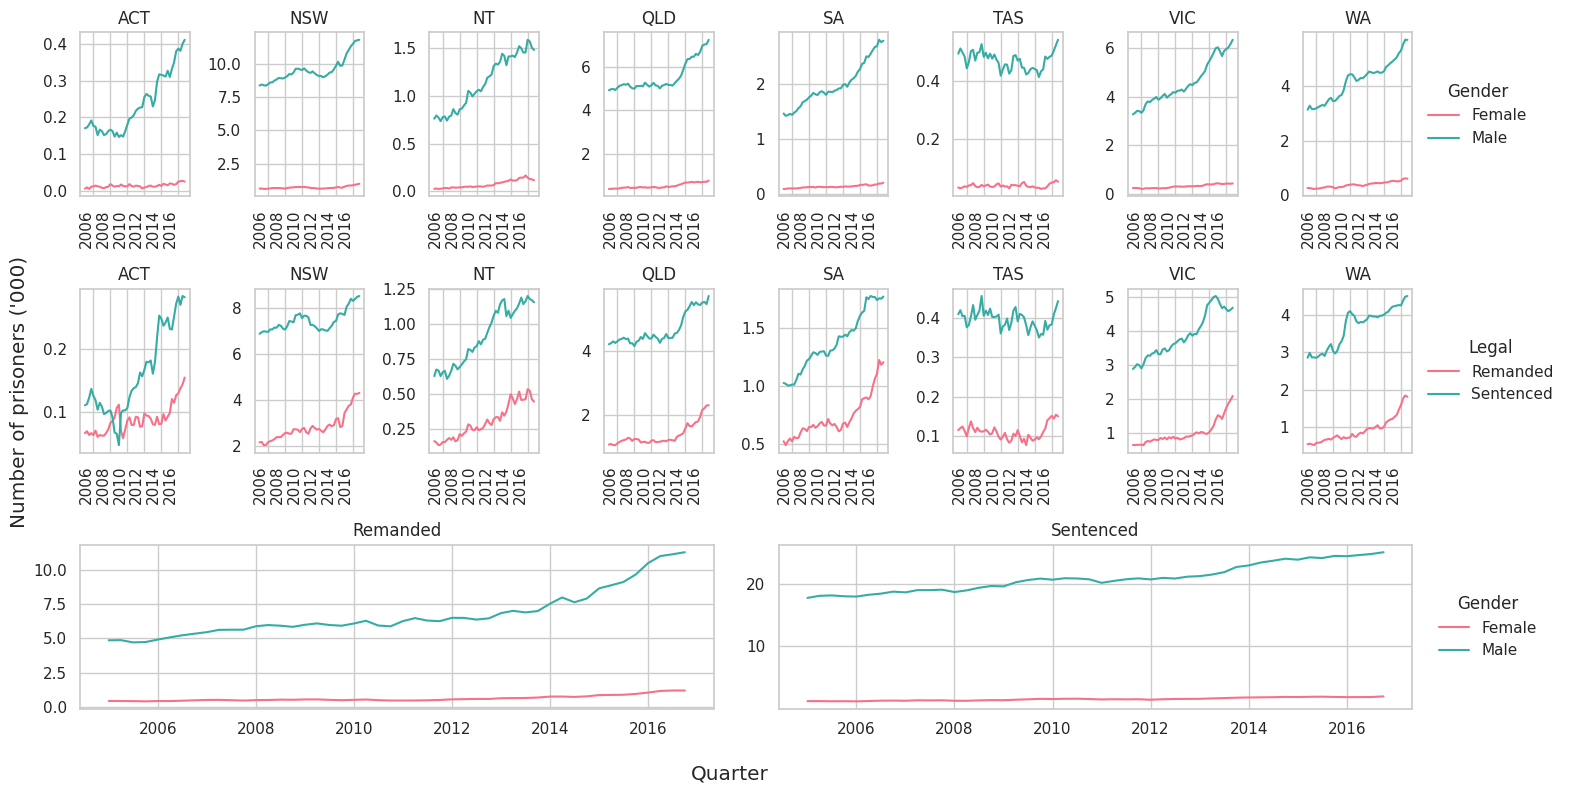

In [20]:
states = list(tags_prison["Country/State"])
genders = prison["Gender"].unique()
legals = prison["Legal"].unique()

state_gender = [f"{state} Gender" for state in states]
state_legal = [f"{state} Legal" for state in states]
legal_gender = 4 * ["Remanded Gender"] + 4 * ["Sentenced Gender"]
mosaic = [state_gender, state_legal, legal_gender]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(16, 8))

for key_column in ("Gender", "Legal"):
    for i, state in enumerate(states):
        labels = prison[key_column].unique()
        label_data = pd.concat(
            [Y_prison_k.loc[f"{state}/{label}"] for label in labels],
            keys=labels,
        ).reset_index(level=0)

        ax = axes[f"{state} {key_column}"]
        sns.lineplot(
            data=label_data,
            x="ds",
            y="y",
            hue="level_0",
            palette="husl",
            ax=ax,
        )
        ax.set_title(state.split("/")[-1])
        ax.set_xlabel("")
        ax.set_ylabel("")
        if i == len(states) - 1:
            ax.legend(
                title=key_column,
                bbox_to_anchor=(1.02, 0.5),
                loc="center left",
                frameon=False,
            )
        else:
            ax.get_legend().remove()
        plt.setp(ax.get_xticklabels(), rotation=90, ha="right")

for i, legal in enumerate(legals):
    label_data = pd.concat(
        [Y_prison_k.loc[f"Australia/{legal}/{gender}"] for gender in genders],
        keys=genders,
    ).reset_index(level=0)
    ax = axes[f"{legal} Gender"]
    sns.lineplot(
        data=label_data,
        x="ds",
        y="y",
        hue="level_0",
        palette="husl",
        ax=ax,
    )
    ax.set_title(legal)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if i == len(legals) - 1:
        ax.legend(
            title="Gender",
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
            frameon=False,
        )
    else:
        ax.get_legend().remove()

fig.supylabel("Number of prisoners ('000)")
fig.supxlabel("Quarter", x=0.47)
fig.tight_layout()
plt.show()

### Bottom-level series by state

Most-disaggregated view used here: `State / Legal / Gender` (summing over Indigenous).

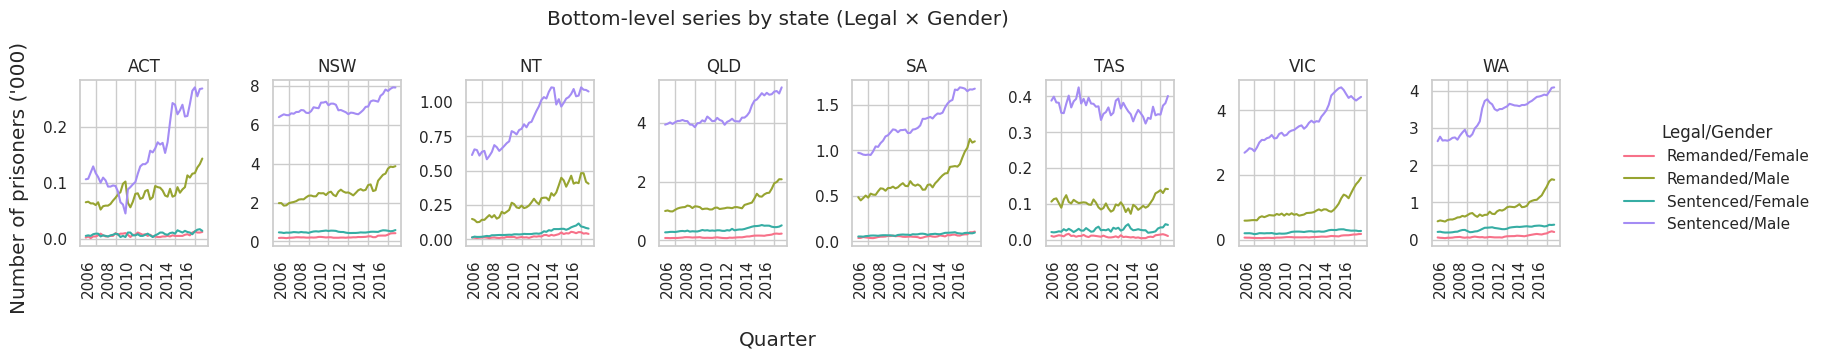

In [21]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(states),
    figsize=(16, 3.5),
    sharey=False,
)

for ax, state in zip(axes, states):
    df = pd.concat(
        [
            Y_prison_k.loc[f"{state}/{legal}/{gender}"].assign(
                key=f"{legal}/{gender}"
            )
            for legal in legals
            for gender in genders
        ]
    )
    sns.lineplot(
        data=df,
        x="ds",
        y="y",
        hue="key",
        palette="husl",
        ax=ax,
    )
    ax.set_title(state.split("/")[-1])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.get_legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Legal/Gender",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False,
)
fig.suptitle("Bottom-level series by state (Legal × Gender)")
fig.supxlabel("Quarter")
fig.supylabel("Number of prisoners ('000)")
fig.tight_layout()
plt.show()

## Mixed hierarchical and grouped structure

Tourism can combine:

- a *nested* geographic hierarchy (Country → State → Region), and
- a *crossed* attribute: *Purpose* of travel (Holiday, Business, Visiting, Other).

Purpose does not nest inside geography — you can look at purpose nationally, by state, or by region.

Compared with the pure geo hierarchy (~85 series), crossing with purpose expands the collection substantially (~425 series).

### Spec that nests and crosses

**Try changing `spec`:**

- Add `["Country"]` → include a national total without purpose.
- Drop `Region` from the finest level → coarser mixed structure (state × purpose only).

In [15]:
mixed_spec = [
    ["Country", "State"],
    ["Country", "Purpose"],
    ["Country", "State", "Purpose"],
    ["Country", "State", "Region", "Purpose"],
]

Y_mixed, S_mixed, tags_mixed = aggregate(
    df=aus_tourism,
    spec=mixed_spec,
)

print("Series at each level:")
for level, unique_ids in tags_mixed.items():
    print(f"  {level}: {len(unique_ids)}")
print(f"\nTotal unique series: {Y_mixed['unique_id'].nunique()}")
display(Y_mixed.head())

Series at each level:
  Country/State: 8
  Country/Purpose: 4
  Country/State/Purpose: 32
  Country/State/Region/Purpose: 304

Total unique series: 348


,unique_id,ds,y
0,Australia/ACT,1998-01-01,551.001921
1,Australia/ACT,1998-04-01,416.025623
2,Australia/ACT,1998-07-01,436.029011
3,Australia/ACT,1998-10-01,449.798445
4,Australia/ACT,1999-01-01,378.572817


### By purpose of travel (national)

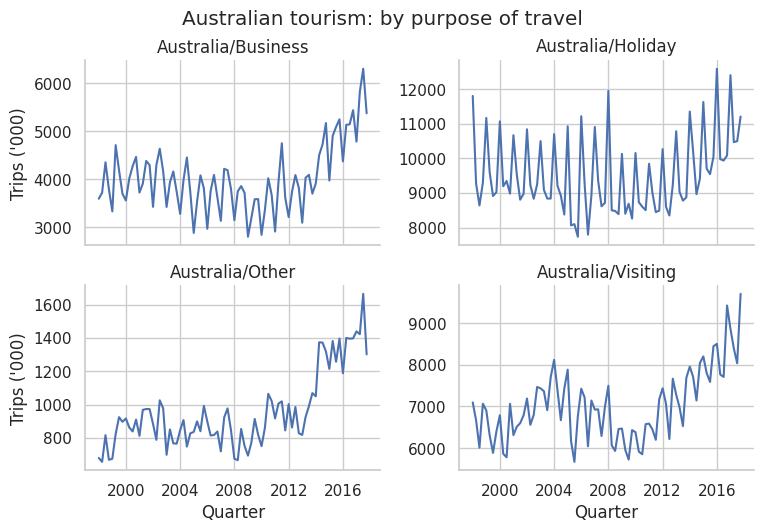

In [16]:
purpose_ids = list(tags_mixed["Country/Purpose"])
purpose_df = Y_mixed.loc[Y_mixed["unique_id"].isin(purpose_ids)].copy()

g = sns.relplot(
    data=purpose_df,
    x="ds",
    y="y",
    col="unique_id",
    col_wrap=2,
    kind="line",
    height=2.6,
    aspect=1.5,
    facet_kws={"sharey": False},
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Quarter", "Trips ('000)")
g.fig.suptitle("Australian tourism: by purpose of travel", y=1.02)
plt.show()

### Purpose crossed with state

Each panel is one state; hues are purposes — mixed nesting (state) and crossing (purpose).

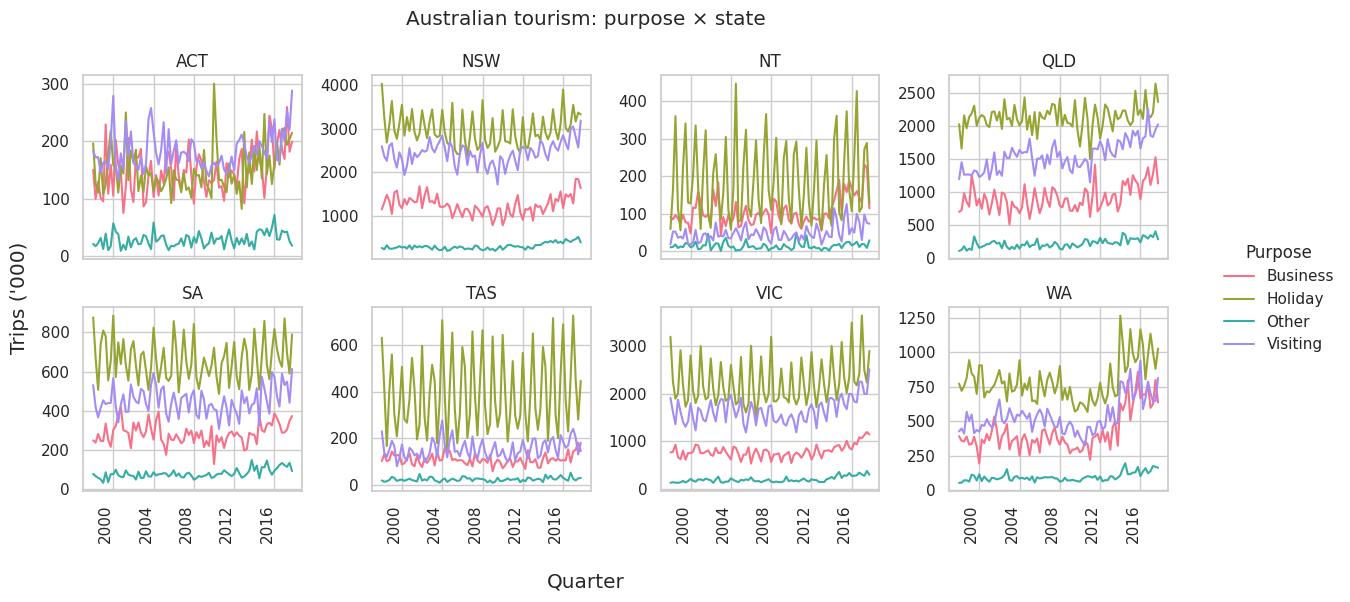

In [17]:
Y_mixed_idx = Y_mixed.set_index("unique_id")
purposes = aus_tourism["Purpose"].unique()
states = tags_mixed["Country/State"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(12, 6),
    sharex=True,
)

for ax, state in zip(axes.flat, states):
    label_df = pd.concat(
        [Y_mixed_idx.loc[f"{state}/{purpose}"] for purpose in purposes],
        keys=purposes,
    ).reset_index(level=0)
    sns.lineplot(
        data=label_df,
        x="ds",
        y="y",
        hue="level_0",
        palette="husl",
        ax=ax,
    )
    ax.set_title(state.split("/")[-1])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.get_legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Purpose",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False,
)
fig.suptitle("Australian tourism: purpose × state")
fig.supylabel("Trips ('000)")
fig.supxlabel("Quarter")
fig.tight_layout()
plt.show()

## Takeaways

- `aggregate(df, spec=...)` builds all levels you need from bottom-level keys.
- *Hierarchical* `spec`: nested lists (`Country` → `State` → `Region`).
- *Grouped* `spec`: parallel / crossed lists (state vs gender vs legal).
- *Mixed* `spec`: nest some factors, cross others (geo × purpose).
- `S_df` and `tags` encode how series roll up — the foundation for *coherent* forecasting later.